<div align="justify">

# **Data Engineering:** *Engenharia de Dados*

Este documento tem como **objetivo principal** analisar um banco de dados real relacionado ao mercado de trabalho na área de ciência de dados. A proposta é compreender, de forma aprofundada, as tendências salariais, as oportunidades internacionais, o potencial de crescimento da carreira na subárea de **engenharia de dados** e, adicionalmente, indicar (com base em fontes externas ao banco) a formação acadêmica recomendada para profissionais que desejam atuar como engenheiros de dados.

</div>

<div align="justify">

## **Grupo**
- João Pedro Caçula dos Santos
- Juan Matheus de Oliveira Lopes
- Julia Miranda da Silva Santana
- Kevin Joel Guzman Alaca
- Patrick Muniz de Aguiar
- Sofia de Souza Carvalho

</div>

<div align="justify">

## **Sobre o Banco de Dados**
*Jobs and Salaries in Data Science* é um banco de dados que reúne informações salariais e características de vagas na área de dados como:

- **work_year:** Ano em que os dados foram coletados.
- **job_title:** Nome do cargo.
- **salary:** Salário da função.
- **experience_level:** Nível de hierarquia de experiência.
- **work_setting:** Tipo de trabalho (Remoto, Híbrido, Presencial...)

No atual cenário em que vivemos, a área de dados cresce cada vez mais. Dessa forma, esse banco nos auxilia a entender quais categorias possuem melhor remuneração, mais concorrência e até mesmo em quais regiões possuem o maior número desses funcionários.

O banco de dados é gratuito e pode ser acessado pelo [Kaggle](https://www.kaggle.com/datasets/hummaamqaasim/jobs-in-data/data).

</div>

<div align="justify">

## **Download do banco de dados**
Para realizar o download do nosso banco, usaremos o [kagglehub](https://github.com/Kaggle/kagglehub), uma biblioteca que permite interagir com recursos do [Kaggle](https://www.kaggle.com/).

> 💡 Os arquivos de recursos são baixados para uma pasta de cache local



</div>

In [ ]:
import kagglehub

try:
  # Tenta acessar a biblioteca do Kaggle e fazer o download do dataframe
  kagglehub.dataset_download("hummaamqaasim/jobs-in-data")
  print('Download concluído!')
except:
  print('Erro no download, tente novamente!')

Using Colab cache for faster access to the 'jobs-in-data' dataset.
Download concluído!


## **Importação das bibliotecas**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Leitura dos dados**

In [ ]:
df = pd.read_csv("/kaggle/input/jobs-in-data/jobs_in_data.csv")

ou, caso possua-o no **Google Drive**:

In [ ]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/jobs_in_data.csv')

<div align="justify">

## **Análise Inicial dos Dados**
Uma **Análise Exploratória de Dados (EDA)** já foi conduzida para esse banco de dados, portanto, prosseguiremos com o Dataframe contendo apenas informações referentes aos cargos de **'Data Engineering'**.

</div>

In [ ]:
df_cargo = df[df['job_category'] == 'Data Engineering'].copy()

In [ ]:
df_cargo.shape

(2260, 12)

In [ ]:
df_cargo.columns

Index(['work_year', 'job_title', 'job_category', 'salary_currency', 'salary',
       'salary_in_usd', 'employee_residence', 'experience_level',
       'employment_type', 'work_setting', 'company_location', 'company_size'],
      dtype='object')

In [ ]:
df_cargo.head(5)

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
9,2023,Data Engineer,Data Engineering,USD,210000,210000,United States,Executive,Full-time,Remote,United States,M
10,2023,Data Engineer,Data Engineering,USD,168000,168000,United States,Executive,Full-time,Remote,United States,M
33,2023,Data Engineer,Data Engineering,USD,185900,185900,United States,Senior,Full-time,In-person,United States,M
34,2023,Data Engineer,Data Engineering,USD,129300,129300,United States,Senior,Full-time,In-person,United States,M


In [ ]:
df_cargo.tail(5)

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
9321,2021,Data Engineer,Data Engineering,EUR,65000,76833,Romania,Senior,Full-time,Hybrid,United Kingdom,S
9324,2021,Big Data Engineer,Data Engineering,USD,18000,18000,Moldova,Mid-level,Full-time,In-person,Moldova,S
9340,2021,Data Engineer,Data Engineering,EUR,38400,45391,Netherlands,Mid-level,Full-time,Remote,Netherlands,L
9344,2020,Data Engineer,Data Engineering,USD,130800,130800,Spain,Mid-level,Full-time,Remote,United States,M
9349,2021,Data Engineer,Data Engineering,EUR,24000,28369,Malta,Mid-level,Full-time,Hybrid,Malta,L


In [ ]:
df_cargo.sample(10)

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
7615,2022,Data Engineer,Data Engineering,USD,160000,160000,United States,Mid-level,Full-time,Remote,United States,M
802,2023,Data Engineer,Data Engineering,USD,167500,167500,United States,Mid-level,Full-time,In-person,United States,M
6568,2023,Data Engineer,Data Engineering,USD,149600,149600,United States,Mid-level,Full-time,In-person,United States,M
3627,2023,Data Engineer,Data Engineering,USD,199000,199000,United Kingdom,Senior,Full-time,In-person,United Kingdom,M
7199,2023,Data Engineer,Data Engineering,USD,175000,175000,United States,Mid-level,Full-time,In-person,United States,M
5030,2023,Data Engineer,Data Engineering,USD,250000,250000,United States,Executive,Full-time,Remote,United States,M
1482,2023,Data Engineer,Data Engineering,USD,123000,123000,United States,Senior,Full-time,In-person,United States,M
4672,2023,Data Engineer,Data Engineering,USD,142200,142200,United States,Senior,Full-time,In-person,United States,M
7967,2022,Data Engineer,Data Engineering,USD,102000,102000,United States,Senior,Full-time,In-person,United States,M
2273,2023,Data Engineer,Data Engineering,USD,181500,181500,United States,Senior,Full-time,In-person,United States,M


In [ ]:
df_cargo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2260 entries, 0 to 9349
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2260 non-null   int64 
 1   job_title           2260 non-null   object
 2   job_category        2260 non-null   object
 3   salary_currency     2260 non-null   object
 4   salary              2260 non-null   int64 
 5   salary_in_usd       2260 non-null   int64 
 6   employee_residence  2260 non-null   object
 7   experience_level    2260 non-null   object
 8   employment_type     2260 non-null   object
 9   work_setting        2260 non-null   object
 10  company_location    2260 non-null   object
 11  company_size        2260 non-null   object
dtypes: int64(3), object(9)
memory usage: 229.5+ KB


## **Remover as colunas 'job_category' e 'salary'**

Como a coluna **`job_category`** possui apenas um tipo de valor e a coluna **`salary`**  se refere aos mesmos valores da coluna **`salary_in_usd`**, removeremos ambas.

In [ ]:
df_reduzido = df_cargo.drop(columns = ['job_category', 'salary']).copy()

In [ ]:
df_reduzido.shape

(2260, 10)

<div align="justify">

## **Informações Faltantes e Duplicatas**

</div>

In [ ]:
df_cargo.isnull().sum()

,0
work_year,0
job_title,0
job_category,0
salary_currency,0
salary,0
salary_in_usd,0
employee_residence,0
experience_level,0
employment_type,0
work_setting,0


Não existem valores nulos em nosso DataFrame

In [ ]:
df_reduzido.duplicated().sum()

np.int64(1100)

In [ ]:
df_reduzido = df_reduzido.drop_duplicates()

In [ ]:
df_reduzido.duplicated().sum()

np.int64(0)

In [ ]:
df_reduzido.T.duplicated().sum()

np.int64(0)

In [ ]:
df_reduzido.shape

(1160, 10)

## **Transformar object em category**

In [ ]:
df_reduzido.dtypes

,0
work_year,int64
job_title,object
salary_currency,object
salary_in_usd,int64
employee_residence,object
experience_level,object
employment_type,object
work_setting,object
company_location,object
company_size,object


In [ ]:
colunas_object = df_reduzido.select_dtypes(include='object').columns

print(colunas_object)

Index(['job_title', 'salary_currency', 'employee_residence',
       'experience_level', 'employment_type', 'work_setting',
       'company_location', 'company_size'],
      dtype='object')


In [ ]:
df_tratado = df_reduzido.copy()

for coluna in colunas_object:
  df_tratado[coluna] = df_tratado[coluna].astype('category')

In [ ]:
df_tratado.dtypes

,0
work_year,int64
job_title,category
salary_currency,category
salary_in_usd,int64
employee_residence,category
experience_level,category
employment_type,category
work_setting,category
company_location,category
company_size,category


## **Tradução do Dataframe**

### Tradução das colunas

In [ ]:
novos_nomes = {
    'work_year': 'ano_trabalho',
    'job_title': 'cargo',
    'salary_currency': 'moeda_salario',
    'salary_in_usd': 'salario_dolar',
    'employee_residence': 'residencia_funcionario',
    'experience_level': 'nivel_experiencia',
    'employment_type': 'tipo_contrato',
    'work_setting': 'modelo_trabalho',
    'company_location': 'localizacao_empresa',
    'company_size': 'porte_empresa'
}

df_traduzido = df_tratado.rename(columns=novos_nomes).copy()

display(df_traduzido.columns)

Index(['ano_trabalho', 'cargo', 'moeda_salario', 'salario_dolar',
       'residencia_funcionario', 'nivel_experiencia', 'tipo_contrato',
       'modelo_trabalho', 'localizacao_empresa', 'porte_empresa'],
      dtype='object')

### Tradução dos valores

In [ ]:
# Identificando os valores únicos de cada coluna categórica
colunas_categoricas = df_traduzido.select_dtypes(include = 'category').columns

for coluna in colunas_categoricas:
  print(f'Coluna: {coluna} \n {list(df_traduzido[coluna].unique())} \n\n ----- \n')

Coluna: cargo 
 ['Data DevOps Engineer', 'Data Engineer', 'Data Integration Engineer', 'ETL Developer', 'Azure Data Engineer', 'Data Infrastructure Engineer', 'Principal Data Engineer', 'Consultant Data Engineer', 'Software Data Engineer', 'Cloud Data Engineer', 'ETL Engineer', 'Big Data Engineer', 'BI Data Engineer', 'Marketing Data Engineer', 'Lead Data Engineer'] 

 ----- 

Coluna: moeda_salario 
 ['EUR', 'USD', 'GBP', 'CAD', 'PLN', 'SGD', 'AUD', 'TRY'] 

 ----- 

Coluna: residencia_funcionario 
 ['Germany', 'United States', 'United Kingdom', 'Canada', 'South Africa', 'France', 'Colombia', 'India', 'Mauritius', 'Poland', 'Brazil', 'Spain', 'Italy', 'Estonia', 'Peru', 'Argentina', 'Netherlands', 'Singapore', 'Slovenia', 'Mexico', 'Nigeria', 'Ireland', 'Sweden', 'Portugal', 'Lithuania', 'Australia', 'Greece', 'Puerto Rico', 'Pakistan', 'Austria', 'Turkey', 'New Zealand', 'Romania', 'Hong Kong', 'Moldova', 'Malta'] 

 ----- 

Coluna: nivel_experiencia 
 ['Mid-level', 'Executive', 'Seni

In [ ]:
# Tradução dos valores da coluna 'cargo'
cargo = {
    'Data DevOps Engineer': 'Engenheiro de DevOps de Dados',
    'Data Engineer': 'Engenheiro de Dados',
    'Data Integration Engineer': 'Engenheiro de Integração de Dados',
    'ETL Developer': 'Desenvolvedor ETL',
    'Azure Data Engineer': 'Engenheiro de Dados Azure',
    'Data Infrastructure Engineer': 'Engenheiro de Infraestrutura de Dados',
    'Principal Data Engineer': 'Engenheiro de Dados Principal',
    'Consultant Data Engineer': 'Consultor de Engenharia de Dados',
    'Software Data Engineer': 'Engenheiro de Software de Dados',
    'Cloud Data Engineer': 'Engenheiro de Dados em Cloud',
    'ETL Engineer': 'Engenheiro ETL',
    'Big Data Engineer': 'Engenheiro de Big Data',
    'BI Data Engineer': 'Engenheiro de Dados de BI',
    'Marketing Data Engineer': 'Engenheiro de Dados de Marketing',
    'Lead Data Engineer': 'Líder de Engenharia de Dados'
}

df_traduzido['cargo'] = df_traduzido['cargo'].map(cargo)

In [ ]:
# Tradução dos valores da coluna 'residencia_funcionario'
residencia_funcionario = {
    'Germany': 'Alemanha',
    'United States': 'Estados Unidos',
    'United Kingdom': 'Reino Unido',
    'Canada': 'Canadá',
    'South Africa': 'África do Sul',
    'France': 'França',
    'Colombia': 'Colômbia',
    'India': 'Índia',
    'Mauritius': 'Ilhas Maurício',
    'Poland': 'Polônia',
    'Brazil': 'Brasil',
    'Spain': 'Espanha',
    'Italy': 'Itália',
    'Estonia': 'Estônia',
    'Peru': 'Peru',
    'Argentina': 'Argentina',
    'Netherlands': 'Países Baixos',
    'Singapore': 'Singapura',
    'Slovenia': 'Eslovênia',
    'Mexico': 'México',
    'Nigeria': 'Nigéria',
    'Ireland': 'Irlanda',
    'Sweden': 'Suécia',
    'Portugal': 'Portugal',
    'Lithuania': 'Lituânia',
    'Australia': 'Austrália',
    'Greece': 'Grécia',
    'Puerto Rico': 'Porto Rico',
    'Pakistan': 'Paquistão',
    'Austria': 'Áustria',
    'Turkey': 'Turquia',
    'New Zealand': 'Nova Zelândia',
    'Romania': 'Romênia',
    'Hong Kong': 'Hong Kong',
    'Moldova': 'Moldávia',
    'Malta': 'Malta'
}

df_traduzido['residencia_funcionario'] = df_traduzido['residencia_funcionario'].map(residencia_funcionario)

In [ ]:
# Tradução dos valores da coluna 'nivel_experiencia'
nivel_experiencia = {
    'Mid-level': 'Pleno',
    'Executive': 'Executivo',
    'Senior': 'Sênior',
    'Entry-level': 'Júnior',
}

df_traduzido['nivel_experiencia'] = df_traduzido['nivel_experiencia'].map(nivel_experiencia)

In [ ]:
# Tradução dos valores da coluna 'tipo_contrato'
tipo_contrato = {
    'Full-time': 'Tempo Integral',
    'Contract': 'Contrato',
    'Freelance': 'Freelance',
    'Part-time': 'Meio Período'
}

df_traduzido['tipo_contrato'] = df_traduzido['tipo_contrato'].map(tipo_contrato)

In [ ]:
# Tradução dos valores da coluna 'modelo_trabalho'
modelo_trabalho = {
    'Hybrid': 'Híbrido',
    'Remote': 'Remoto',
    'In-person': 'Presencial'
}

df_traduzido['modelo_trabalho'] = df_traduzido['modelo_trabalho'].map(modelo_trabalho)

In [ ]:
# Tradução dos valores da coluna 'localizacao_empresa'
localizacao_empresa = {
    'Germany': 'Alemanha',
    'United States': 'Estados Unidos',
    'United Kingdom': 'Reino Unido',
    'Canada': 'Canadá',
    'South Africa': 'África do Sul',
    'France': 'França',
    'Colombia': 'Colômbia',
    'India': 'Índia',
    'Mauritius': 'Ilhas Maurício',
    'Poland': 'Polônia',
    'Brazil': 'Brasil',
    'Spain': 'Espanha',
    'Italy': 'Itália',
    'Estonia': 'Estônia',
    'Peru': 'Peru',
    'Argentina': 'Argentina',
    'Netherlands': 'Países Baixos',
    'Singapore': 'Singapura',
    'Slovenia': 'Eslovênia',
    'Mexico': 'México',
    'Nigeria': 'Nigéria',
    'Ireland': 'Irlanda',
    'Sweden': 'Suécia',
    'Portugal': 'Portugal',
    'Lithuania': 'Lituânia',
    'Australia': 'Austrália',
    'Greece': 'Grécia',
    'Puerto Rico': 'Porto Rico',
    'Pakistan': 'Paquistão',
    'Austria': 'Áustria',
    'Turkey': 'Turquia',
    'New Zealand': 'Nova Zelândia',
    'Romania': 'Romênia',
    'Hong Kong': 'Hong Kong',
    'Moldova': 'Moldávia',
    'Malta': 'Malta'
}

df_traduzido['localizacao_empresa'] = df_traduzido['localizacao_empresa'].map(localizacao_empresa)

In [ ]:
# Tradução dos valores da coluna 'porte_empresa'
porte_empresa = {
    'L': 'Grande',
    'M': 'Médio',
    'S': 'Pequeno'
}

df_traduzido['porte_empresa'] = df_traduzido['porte_empresa'].map(porte_empresa)

## **Ordenação de Hierarquias**

In [ ]:
df_ordenado = df_traduzido.copy()

In [ ]:
ordem = ['Júnior', 'Pleno', 'Sênior', 'Executivo']

df_ordenado['nivel_experiencia'] = pd.Categorical(
    df_ordenado['nivel_experiencia'],
    categories=ordem,
    ordered=True
)

df_ordenado.sort_values('nivel_experiencia').head()

,ano_trabalho,cargo,moeda_salario,salario_dolar,residencia_funcionario,nivel_experiencia,tipo_contrato,modelo_trabalho,localizacao_empresa,porte_empresa
7102,2023,Engenheiro de Dados,USD,160000,Estados Unidos,Júnior,Tempo Integral,Presencial,Estados Unidos,Médio
9098,2022,Engenheiro de Dados,EUR,55475,Paquistão,Júnior,Tempo Integral,Remoto,Alemanha,Médio
9086,2020,Engenheiro de Dados,EUR,54742,Paquistão,Júnior,Tempo Integral,Remoto,Alemanha,Grande
9071,2022,Engenheiro de Dados,USD,65000,Estados Unidos,Júnior,Tempo Integral,Remoto,Estados Unidos,Pequeno
1005,2023,Engenheiro de Dados,USD,88000,Estados Unidos,Júnior,Tempo Integral,Presencial,Estados Unidos,Médio


## **Estatísticas descritivas**

In [ ]:
df_ordenado.describe()

,ano_trabalho,salario_dolar
count,1160.000000,1160.000000
mean,2022.633621,142967.543103
std,0.629508,61846.133023
min,2020.000000,18000.000000
25%,2022.000000,96820.500000
50%,2023.000000,135000.000000
75%,2023.000000,183077.500000
max,2023.000000,385000.000000


In [ ]:
df_ordenado.describe(include = ['category'])

,cargo,moeda_salario,residencia_funcionario,nivel_experiencia,tipo_contrato,modelo_trabalho,localizacao_empresa,porte_empresa
count,1160,1160,1160,1160,1160,1160,1160,1160
unique,15,8,36,4,4,3,32,3
top,Engenheiro de Dados,USD,Estados Unidos,Sênior,Tempo Integral,Presencial,Estados Unidos,Médio
freq,1100,997,915,734,1155,615,922,1059


## **Análises e discussões**

In [ ]:
df_analise = df_ordenado.copy()

### Distribuição salarial

In [ ]:
media_salarial = df_analise['salario_dolar'].mean()

print(f'A média salarial do cargo de Data Engineer é de ${round(media_salarial, 2)} dólares.')

A média salarial do cargo de Data Engineer é de $142967.54 dólares.


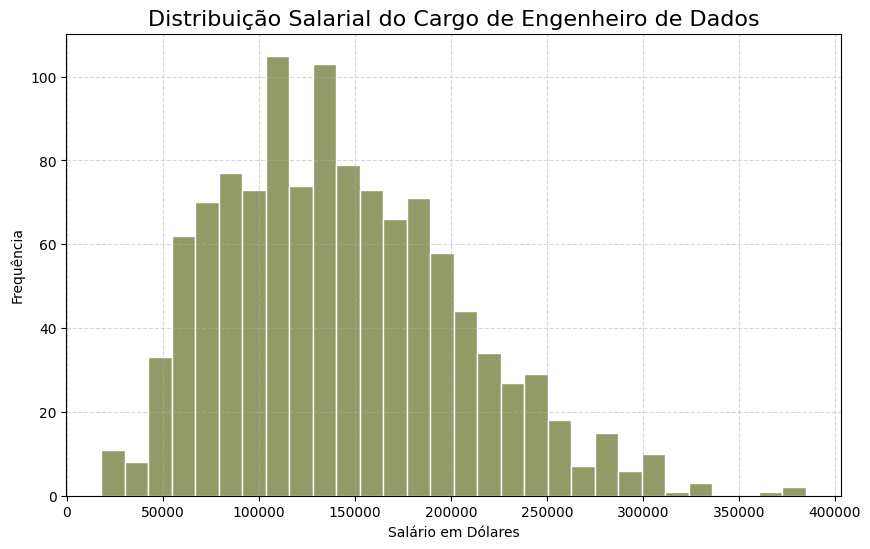

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_analise['salario_dolar'], bins = 30, linewidth = 1, edgecolor = 'white', color = '#929a68')

plt.title('Distribuição Salarial do Cargo de Engenheiro de Dados', fontsize = 16)
plt.xlabel('Salário em Dólares', fontsize = 10)
plt.ylabel('Frequência', fontsize = 10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('grafico1')
plt.show()

Percebe-se que os salários apresentam uma distribuição assimétrica à direita, com maior concentração de frequências entre 50.000,00 e 200.000,00 dólares, e pico principal entre 100.000,00 e 150.000,00. Embora a média salarial geral seja de aproximadamente 142.967,54 dólares anuais, esse valor representa de forma parcial os salários do cargo, pois é influenciado pela cauda longa de remunerações elevadas (acima de 250.000,00), sendo mais adequado utilizar a moda ou a mediana (em torno de 115.000,00 a 130.000,00) para descrever o salário típico da maioria dos profissionais. Fatores como experiência profissional, localização geográfica, porte da empresa, habilidades técnicas e outros fatores influênciam significativamente sobre essa média salarial.

### Países com mais oportunidades de trabalho

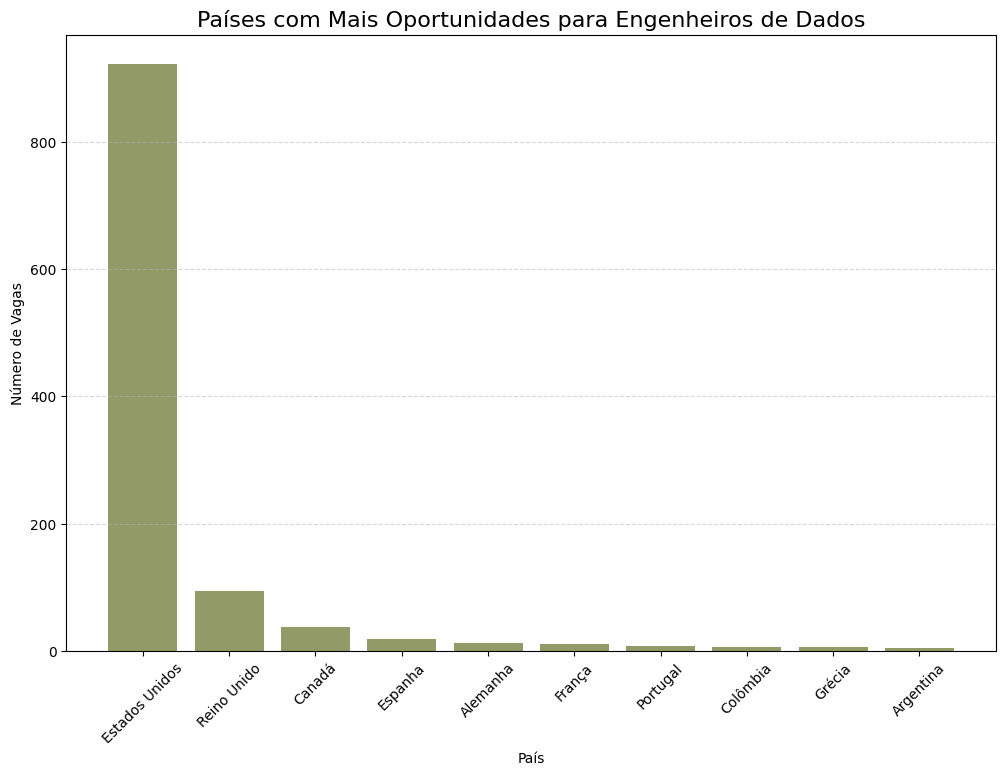

In [ ]:
paises = df_analise['localizacao_empresa'].value_counts().head(10)

plt.figure(figsize=(12, 8))
plt.bar(paises.index, paises.values, color = '#929a68')

plt.title('Países com Mais Oportunidades para Engenheiros de Dados', fontsize = 16)
plt.xlabel('País', fontsize = 10)
plt.ylabel('Número de Vagas', fontsize = 10)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

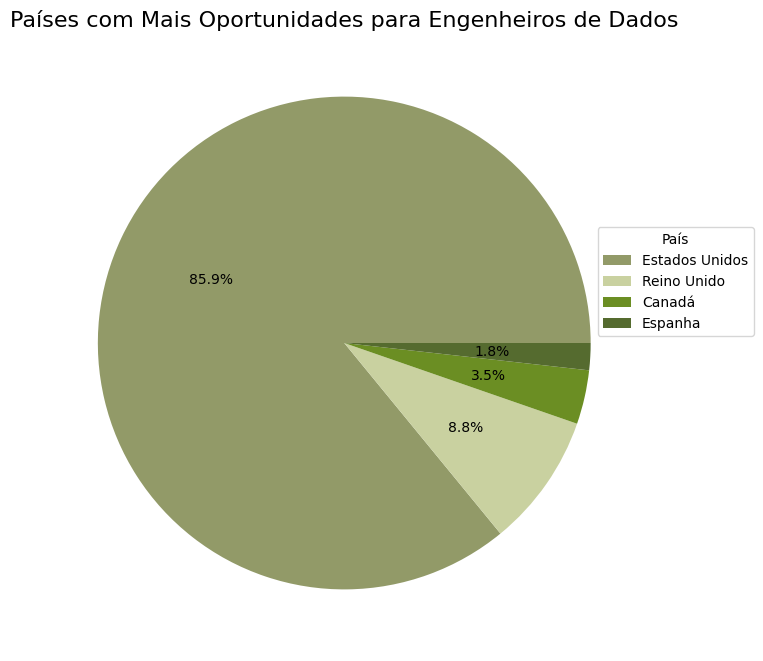

In [ ]:
paises = df_analise['localizacao_empresa'].value_counts().head(4)

plt.figure(figsize=(12, 8))
plt.pie(paises.values, autopct='%1.1f%%', colors=['#929a68', '#c9d1a0', '#6b8e23', '#556b2f'])

plt.title('Países com Mais Oportunidades para Engenheiros de Dados', fontsize = 16)
plt.legend(paises.index, title='País', fontsize = 10, bbox_to_anchor=(0.9, 0.5))

plt.show()

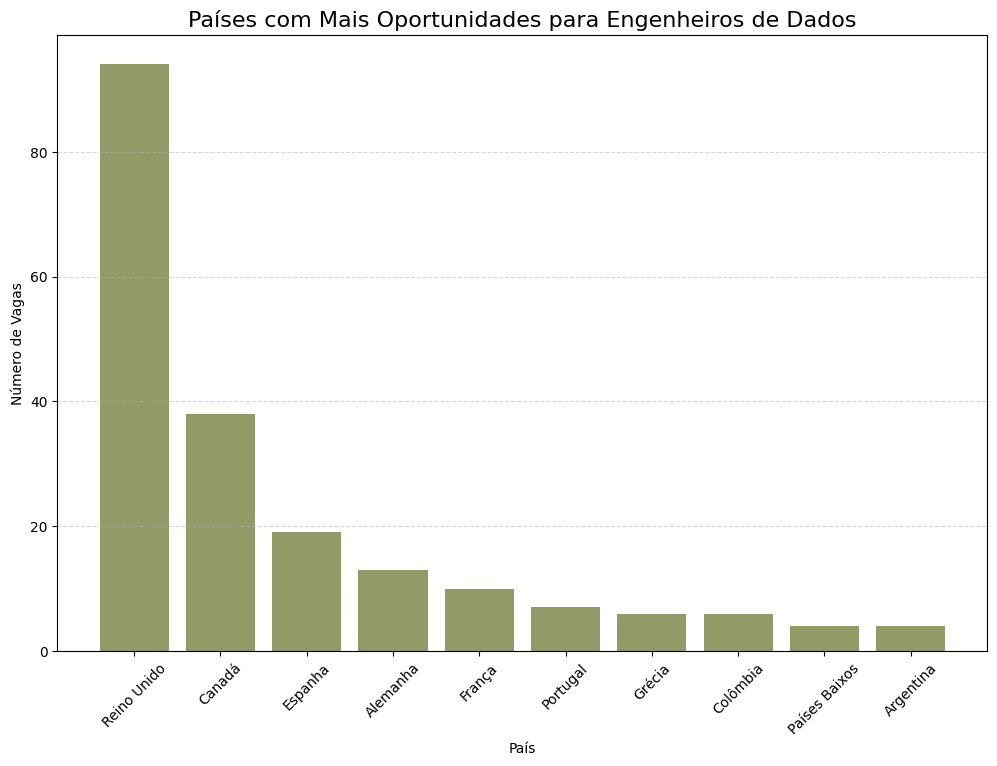

In [ ]:
df_sem_eua = df_analise[
    df_analise['localizacao_empresa'] != 'Estados Unidos'
].copy()

paises = df_sem_eua['localizacao_empresa'].value_counts().head(10)

plt.figure(figsize=(12, 8))
plt.bar(paises.index, paises.values, color = '#929a68')

plt.title('Países com Mais Oportunidades para Engenheiros de Dados', fontsize = 16)
plt.xlabel('País', fontsize = 10)
plt.ylabel('Número de Vagas', fontsize = 10)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Potencial de crescimento da carreira

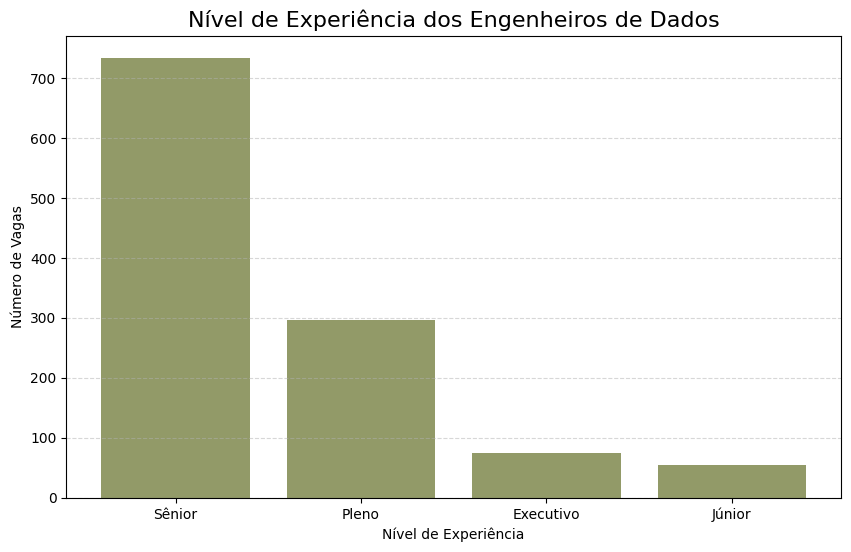

In [ ]:
frequencia = df_analise['nivel_experiencia'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(frequencia.index, frequencia.values, color = '#929a68')

plt.title('Nível de Experiência dos Engenheiros de Dados', fontsize = 16)
plt.xlabel('Nível de Experiência', fontsize = 10)
plt.ylabel('Número de Vagas', fontsize = 10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Evolução da média salarial por Nivel de experiência ao longo dos anos

/tmp/ipykernel_12996/1665951735.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_salarial_por_nivel_e_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia'])['salario_dolar'].mean().reset_index()


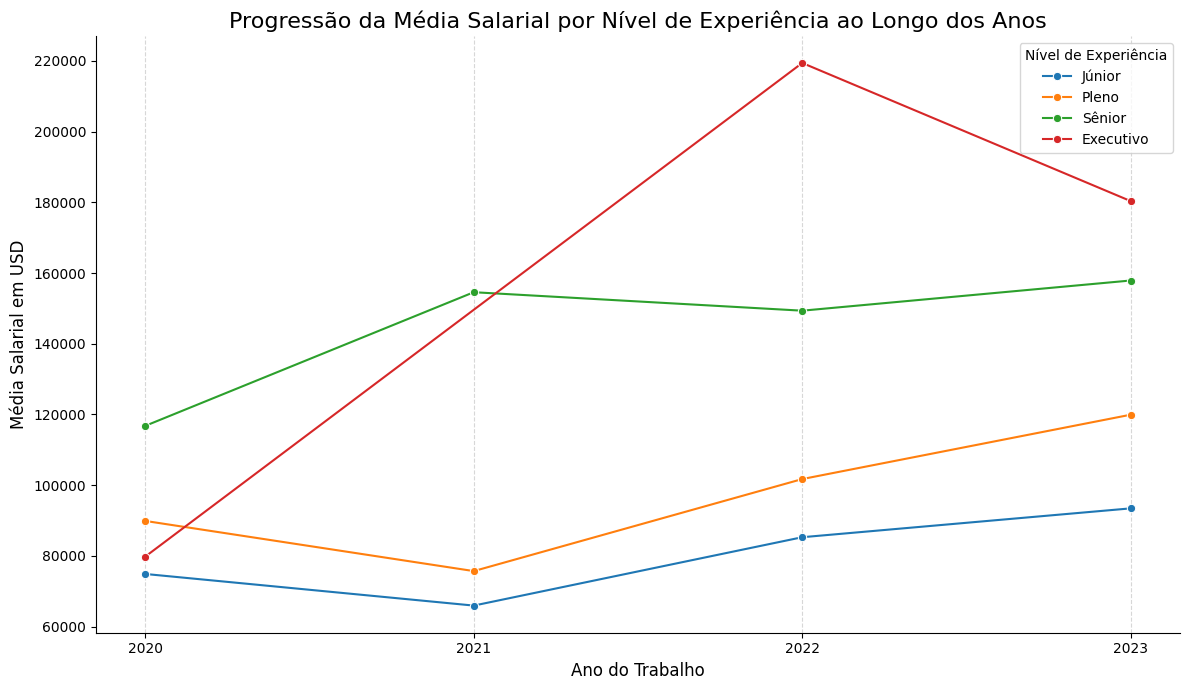

In [ ]:
import seaborn as sns

# Agrupar por ano e nível de experiência para calcular a média salarial
media_salarial_por_nivel_e_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia'])['salario_dolar'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=media_salarial_por_nivel_e_ano,
    x='ano_trabalho',
    y='salario_dolar',
    hue='nivel_experiencia',
    marker='o'
)

plt.title('Progressão da Média Salarial por Nível de Experiência ao Longo dos Anos', fontsize=16)
plt.xlabel('Ano do Trabalho', fontsize=12)
plt.ylabel('Média Salarial em USD', fontsize=12)
plt.xticks(media_salarial_por_nivel_e_ano['ano_trabalho'].unique()) # isso aqui garante que apenas anos INTEIROS sejam exibidos
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Nível de Experiência')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### Potencial de crescimento de Carreira V2

/tmp/ipykernel_12996/1691054971.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  numero_cargos_por_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia']).size().reset_index(name='count')


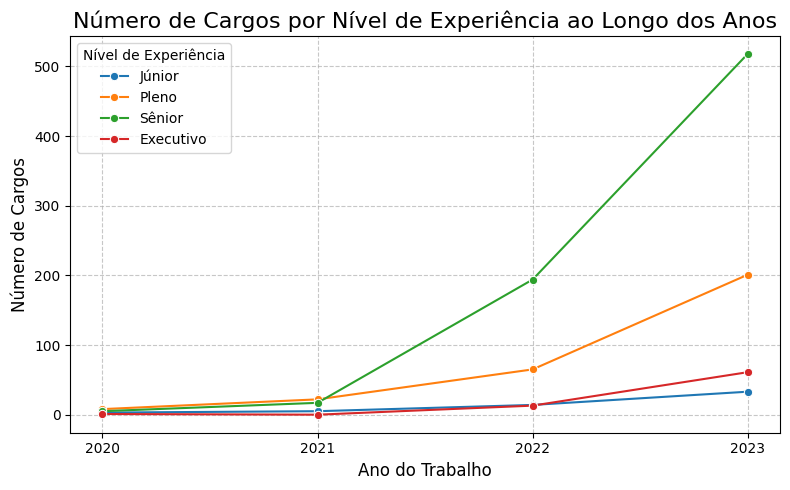

In [ ]:
# Agrupar por ano e nível de experiência para calcular o Número de Cargosao longo dos anos
numero_cargos_por_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia']).size().reset_index(name='count')

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=numero_cargos_por_ano,
    x='ano_trabalho',
    y='count',
    hue='nivel_experiencia',
    marker='o'
)

plt.title('Número de Cargos por Nível de Experiência ao Longo dos Anos', fontsize=16)
plt.xlabel('Ano do Trabalho', fontsize=12)
plt.ylabel('Número de Cargos', fontsize=12)
plt.xticks(numero_cargos_por_ano['ano_trabalho'].unique()) # Garante que apenas anos inteiros sejam exibidos
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Nível de Experiência')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12996/915319379.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  numero_cargos_por_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia']).size().reset_index(name='count')
/tmp/ipykernel_12996/915319379.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  media_salarial_por_nivel_e_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia'])['salario_dolar'].mean().reset_index()


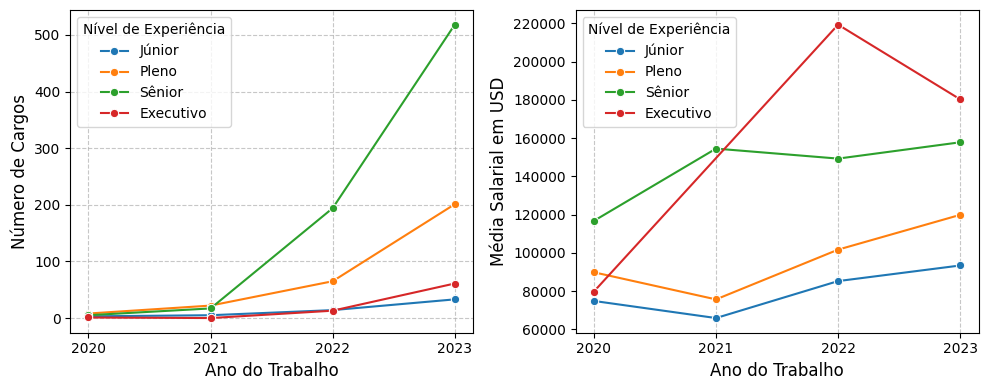

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Agrupar por ano e nível de experiência para calcular o Número de Cargos ao longo dos anos
numero_cargos_por_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia']).size().reset_index(name='count')

# Agrupar por ano e nível de experiência para calcular a média salarial
media_salarial_por_nivel_e_ano = df_analise.groupby(['ano_trabalho', 'nivel_experiencia'])['salario_dolar'].mean().reset_index()

# Criar a figura e os subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # 1 linha, 2 colunas

sns.lineplot(
    data=numero_cargos_por_ano,
    x='ano_trabalho',
    y='count',
    hue='nivel_experiencia',
    marker='o',
    ax=axes[0]
)

axes[0].set_xlabel('Ano do Trabalho', fontsize=12)
axes[0].set_ylabel('Número de Cargos', fontsize=12)
axes[0].set_xticks(numero_cargos_por_ano['ano_trabalho'].unique()) # Garante que apenas anos inteiros sejam exibidos
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title='Nível de Experiência')

sns.lineplot(
    data=media_salarial_por_nivel_e_ano,
    x='ano_trabalho',
    y='salario_dolar',
    hue='nivel_experiencia',
    marker='o',
    ax=axes[1]
)
# axes[1].set_title('Progressão da Média Salarial por Nível de Experiência ao Longo dos Anos', fontsize=16)
axes[1].set_xlabel('Ano do Trabalho', fontsize=12)
axes[1].set_ylabel('Média Salarial em USD', fontsize=12)
axes[1].set_xticks(media_salarial_por_nivel_e_ano['ano_trabalho'].unique()) # isso aqui garante que apenas anos INTEIROS sejam exibidos
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
axes[1].legend(title='Nível de Experiência')
plt.tight_layout()
plt.show()